
Processing: P_{O(I)}
0.10906615671661797


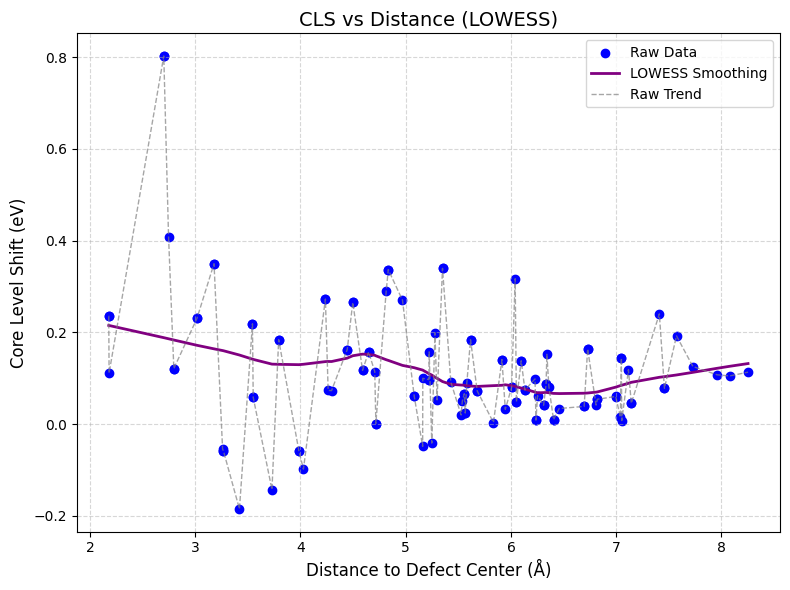


Processing: P_{O(II)}
0.06138887816189068


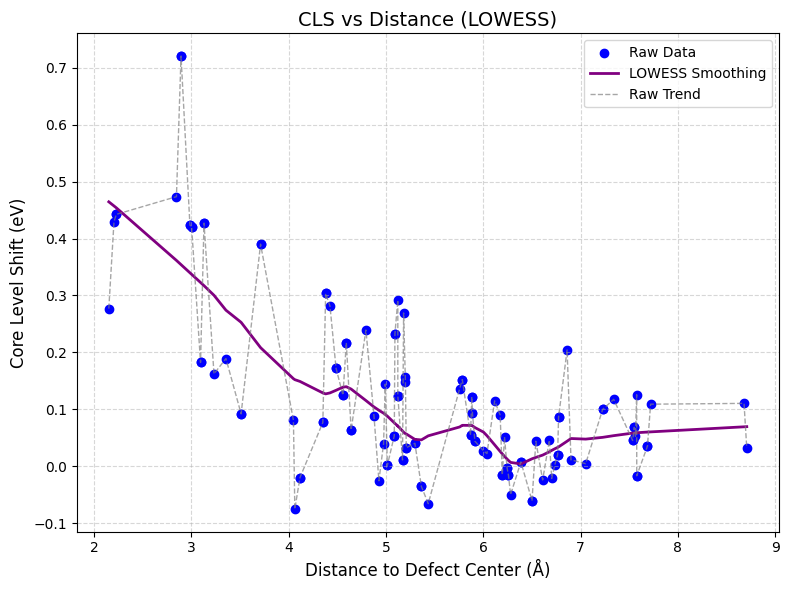


Processing: P_{O(III)}
0.06297735966336473


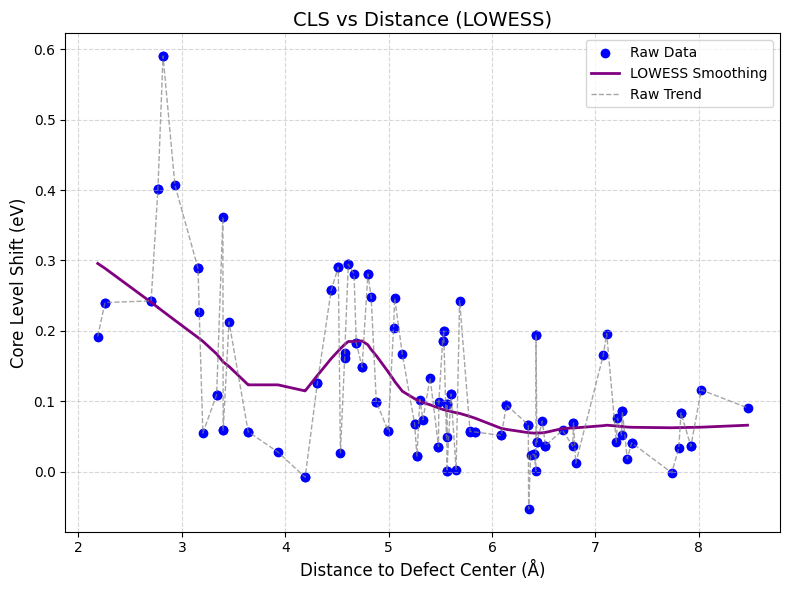

P_{O(I)}: 0.10906615671661797 eV
P_{O(II)}: 0.06138887816189068 eV
P_{O(III)}: 0.06297735966336473 eV


In [3]:
import os
import matplotlib.pyplot as plt
from scipy.interpolate import PchipInterpolator, Akima1DInterpolator
from statsmodels.nonparametric.smoothers_lowess import lowess
from pymatgen.core.structure import Structure
from pymatgen.analysis.structure_matcher import StructureMatcher
from pymatgen.analysis.local_env import CovalentRadius
from pymatgen.io.vasp.inputs import Poscar
import numpy as np
import re

# 工具函数：提取 OUTCAR 中的 1s 芯能级能量
def extract_1s_energies(file_path):
    energies = []
    with open(file_path, 'r') as f:
        for line in f:
            match = re.search(r'1s\s+(-?\d+\.\d+)', line)
            if match:
                energy = float(match.group(1))
                energies.append(energy)
    return energies


# 工具函数：获取结构并对齐
def get_aligned_structures(ref_poscar_path, target_poscar_path, tol=0.1):
    ref_structure = Structure.from_file(ref_poscar_path)
    target_structure = Structure.from_file(target_poscar_path)

    # 确保晶格一致（否则无法直接比较）
    target_structure.lattice = ref_structure.lattice

    return ref_structure, target_structure


# 工具函数：找出缺陷原子
from pymatgen.core import Structure, Lattice
import numpy as np

def find_defect_sites(ref_structure: Structure, target_structure: Structure, distance_tol=0.5):
    """
    找出目标结构相对于参考结构中发生变化的原子索引。
    - 不要求对称性一致
    - 处理原子重排
    - 检测元素变化或显著位移
    """

    # 获取两种结构的分数坐标
    ref_coords = ref_structure.frac_coords
    target_coords = target_structure.frac_coords
    ref_species = [site.specie for site in ref_structure.sites]
    target_species = [site.specie for site in target_structure.sites]

    lattice = ref_structure.lattice  # 用于周期性距离计算

    # 初始化映射表
    matched_indices = set()  # 已经匹配的目标结构原子索引
    defect_indices = []

    # Step 1: 对每个参考原子，在目标结构中找最近的同种原子
    for i, (specie, coord) in enumerate(zip(ref_species, ref_coords)):
        min_dist = float('inf')
        min_idx = -1

        for j, (t_specie, t_coord) in enumerate(zip(target_species, target_coords)):
            if t_specie != specie:
                continue

            # 使用 get_distance_and_image 计算周期性最小距离
            dist, _ = lattice.get_distance_and_image(coord, t_coord)

            if dist < min_dist:
                min_dist = dist
                min_idx = j

        if min_idx == -1 or min_dist > distance_tol:
            # 没有找到匹配项或距离太大 → 原子被替换/删除
            # if min_idx != -1:
            #     defect_indices.append(min_idx)
            pass
        else:
            # 成功匹配
            matched_indices.add(min_idx)

    # Step 2: 检查目标结构中有没有未被匹配的原子 → 插入的原子
    for j in range(len(target_structure)):
        if j not in matched_indices:
            defect_indices.append(j)

    return list(set(defect_indices))

def match_target_to_ref_indices(target_structure, ref_structure, distance_tol=0.5):
    """
    返回一个字典：target_index -> ref_index，表示目标结构中的原子对应参考结构中的哪一个
    """
    lattice = ref_structure.lattice
    target_coords = target_structure.frac_coords
    ref_coords = ref_structure.frac_coords
    target_species = [site.specie for site in target_structure.sites]
    ref_species = [site.specie for site in ref_structure.sites]

    target_to_ref_map = {}  # target_index -> ref_index
    used_ref_indices = set()

    for j in range(len(target_structure)):
        t_specie = target_species[j]
        t_coord = target_coords[j]

        min_dist = float('inf')
        min_idx = -1

        for i in range(len(ref_structure)):
            if ref_species[i] != t_specie:
                continue
            if i in used_ref_indices:
                continue

            dist, _ = lattice.get_distance_and_image(t_coord, ref_coords[i])
            if dist < min_dist:
                min_dist = dist
                min_idx = i

        if min_idx != -1 and min_dist <= distance_tol:
            target_to_ref_map[j] = min_idx
            used_ref_indices.add(min_idx)

    return target_to_ref_map

def get_defect_center_with_pbc(structure: Structure, defect_indices):
    """
    根据缺陷原子索引，考虑周期性边界条件，计算缺陷中心坐标。
    
    参数:
        structure (Structure): 目标结构
        defect_indices (list): 缺陷原子索引列表
    
    返回:
        np.array: 缺陷中心坐标 (cartesian)
    """
    lattice = structure.lattice
    coords = [structure[i].coords for i in defect_indices]
    coords = np.array(coords)

    if len(coords) == 0:
        raise ValueError("No defect atoms provided.")

    # 选第一个缺陷原子作为参考点
    ref_coord = coords[0]

    # 转换为分数坐标
    frac_coords = np.array([lattice.get_fractional_coords(c) for c in coords])

    # 对所有坐标相对于参考点做最小镜像处理
    adjusted_frac_coords = []
    for fc in frac_coords:
        _, image = lattice.get_distance_and_image(fc, lattice.get_fractional_coords(ref_coord))
        adjusted_frac = fc - image
        adjusted_frac_coords.append(adjusted_frac)

    # 转换回笛卡尔坐标并求平均
    adjusted_cart_coords = lattice.get_cartesian_coords(np.array(adjusted_frac_coords))
    defect_center = np.mean(adjusted_cart_coords, axis=0)

    return defect_center

# 主程序逻辑
if __name__ == "__main__":
    path = "/home/bingxing2/ailab/xiazeyu_p/Programs/trash/5.9"
    suffixes = [
        # "Cu_{Ga(I)}", "Cu_{Ga(I)}-N_{O(I)}", "Cu_{Ga(I)}-N_{O(II)}", "Cu_{Ga(I)}-N_{O(III)}", "Cu_{Ga(II)}", "Cu_{Ga(II)}-N_{O(I)}", "Cu_{Ga(II)}-N_{O(II)}", "Cu_{Ga(II)}-N_{O(III)}","Fe_{Ga(I)}", "Fe_{Ga(I)}-N_{O(I)}", "Fe_{Ga(I)}-N_{O(II)}", "Fe_{Ga(I)}-N_{O(III)}", "Fe_{Ga(II)}", "Fe_{Ga(II)}-N_{O(I)}", "Fe_{Ga(II)}-N_{O(II)}", "Fe_{Ga(II)}-N_{O(III)}" 
        "P_{O(I)}", "P_{O(II)}", "P_{O(III)}"
    ]

    biases = []
    ref_poscar = f"/home/bingxing2/ailab/xiazeyu_p/Programs/P-type-Ga2O3/ga48o72/hse06_scf_0_0.32_new/POSCAR"
    ref_outcar = f"/home/bingxing2/ailab/xiazeyu_p/Programs/P-type-Ga2O3/ga48o72/hse06_scf_0_0.32_new/OUTCAR"

    bulk_reference_energies = extract_1s_energies(ref_outcar)

    for s in suffixes:
        print(f"\nProcessing: {s}")

        target_dir = f"{path}/{s}/hse06_scf_-1_0.32"
        target_poscar = f"{target_dir}/POSCAR"
        target_outcar = f"{target_dir}/OUTCAR"

        if not os.path.exists(target_poscar) or not os.path.exists(target_outcar):
            print(f"Missing files for {s}, skipping.")
            continue

        # 1. 获取结构
        ref_structure, target_structure = get_aligned_structures(ref_poscar, target_poscar)

        # 2. 找出缺陷原子索引
        defect_indices = find_defect_sites(ref_structure, target_structure)

        if not defect_indices:
            print("No defects found.")
            continue

        # 3. 缺陷位置的平均坐标
        # defect_coords = [target_structure[i].coords for i in defect_indices]
        # defect_center = np.mean(defect_coords, axis=0)
        defect_center = get_defect_center_with_pbc(target_structure, defect_indices)

        # 4. 提取芯能级能量差
        core_energy_diffs = extract_1s_energies(target_outcar)
        if len(core_energy_diffs) != len(ref_structure):
            print("Length mismatch between structure and energy list.")
            continue

        # 5. 遍历所有非缺陷原子，计算距离与能量差
        results = []
        # print(len(target_structure))

        lattice = target_structure.lattice
        # 建立映射关系
        target_to_ref_map = match_target_to_ref_indices(target_structure, ref_structure)

        for i, site in enumerate(target_structure):
            if i in defect_indices:
                continue

            # 只处理能够匹配到参考原子的那些目标原子
            if i not in target_to_ref_map:
                continue

            ref_idx = target_to_ref_map[i]

            # 使用分数坐标进行周期性距离计算
            frac_defect_center = lattice.get_fractional_coords(defect_center)
            frac_site = site.frac_coords

            # 计算最小镜像距离
            dist, _ = lattice.get_distance_and_image(frac_site, frac_defect_center)

            e_diff = core_energy_diffs[i] - bulk_reference_energies[ref_idx]
            results.append((dist, e_diff))

        # 6. 输出结果：按距离排序
        # 排序结果
        # 排序结果
        # 排序结果
        results.sort()
        distances = np.array([x[0] for x in results])
        shifts = np.array([x[1] for x in results])

        # LOWESS 插值
        lowess_result = lowess(shifts, distances, frac=0.3, it=3)
        dist_lo, shift_lo = lowess_result[:, 0], lowess_result[:, 1]
        biases.append(np.mean(shift_lo[-10:]))
        print(biases[-1])

        # 绘图
        plt.figure(figsize=(8, 6))
        plt.scatter(distances, shifts, color='blue', label='Raw Data')
        plt.plot(dist_lo, shift_lo, color='purple', linewidth=2, label='LOWESS Smoothing')
        
        plt.plot(distances, shifts, color='gray', linestyle='--', linewidth=1, alpha=0.7, label='Raw Trend')
        plt.title("CLS vs Distance (LOWESS)", fontsize=14)
        plt.xlabel("Distance to Defect Center (Å)", fontsize=12)
        plt.ylabel("Core Level Shift (eV)", fontsize=12)
        plt.grid(True, linestyle='--', alpha=0.5)
        plt.legend()
        plt.tight_layout()
        plt.show()

    for i, s in enumerate(suffixes):
        print(f"{s}: {biases[i]} eV")